# RAG Retrieval Evaluation Summary

이 노트북은 지금까지 진행한 retrieval 실험의 최종 보고서다. 모든 평가는 canonical 500문항 기준이며, 생성 평가는 제외하고 검색 성능만 본다.

주요 지표는 `hit@5`, `mrr@5`, `ndcg@5`이고, 다중 문서 질문(type B)은 `multi_doc_recall@5`도 함께 확인한다.


In [52]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 160)

CWD = Path.cwd()
PROJECT_ROOT = CWD if (CWD / "eval").exists() else CWD.parent
EVAL_DIR = PROJECT_ROOT / "eval" / "evaluation" / "outputs" / "eval"
LOG_PATH = EVAL_DIR / "experiment_logs" / "phase1_retrieval_experiments.csv"

ranking = pd.read_csv(EVAL_DIR / "overall_experiment_ranking_by_ndcg.csv")
final_compare = pd.read_csv(EVAL_DIR / "final_setting_comparison.csv")
logs = pd.read_csv(LOG_PATH)

print(f"project root: {PROJECT_ROOT}")
print(f"eval outputs: {EVAL_DIR}")


project root: /home/beomsoo/chatbot
eval outputs: /home/beomsoo/chatbot/eval/evaluation/outputs/eval


## 1. 최종 결론

최종 추천 조합은 **74 KURE-v1 + Chroma metadata + HNSW tuned + diversity250**이다.

- Vector DB: `Chroma`
- 임베딩 모델: `KURE-v1`
- 검색 방식: dense retrieval
- Chroma metadata: `doc_id`, `source_file`, `issuer`, `project_name` 필드 분리 저장
- Chroma HNSW: `ef_search=400`, `ef_construction=200`, `max_neighbors=32`
- Query decomposition: conditional 적용
- 후보 병합: `RRF`
- 최종 문서 선택: `doc_id` 기준 diversity
- `decomposition_candidates_per_query=50`
- `diversity_candidates=250`

`75 diversity300`도 같은 nDCG를 냈지만 더 느렸기 때문에, 성능/시간 균형 기준으로는 `74`가 최종본이다.


In [53]:
best = ranking.iloc[0]
best_summary = pd.DataFrame([
    {
        "rank": int(best["rank"]),
        "experiment_name": best["experiment_name"],
        "hit@5": best["overall_hit_at_5"],
        "mrr@5": best["overall_mrr_at_5"],
        "ndcg@5": best["overall_ndcg_at_5"],
        "typeB_ndcg@5": best["type_b_ndcg_at_5"],
        "typeB_multi_doc_recall@5": best.get("type_b_multi_doc_recall_at_5"),
        "elapsed": best["elapsed"],
    }
])
best_summary


,rank,experiment_name,hit@5,mrr@5,ndcg@5,typeB_ndcg@5,typeB_multi_doc_recall@5,elapsed
0,1,74_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per50_diverse250_soyeon_125_kure_chroma_hnsw_tuned_can...,1.0,0.973833,0.959371,0.9149,0.95,1:29.39


## 2. 최종 후보 비교

아래 표는 최종 의사결정에 사용한 핵심 후보들만 모은 것이다. 전체 로그는 `phase1_retrieval_experiments.csv`에 누적되어 있다.


In [54]:
final_view = final_compare[[
    "setting", "rank", "overall_hit_at_5", "overall_mrr_at_5", "overall_ndcg_at_5",
    "type_b_ndcg_at_5", "type_b_multi_doc_recall_at_5", "elapsed", "notes",
]].copy()

final_view.head(12)


,setting,rank,overall_hit_at_5,overall_mrr_at_5,overall_ndcg_at_5,type_b_ndcg_at_5,type_b_multi_doc_recall_at_5,elapsed,notes
0,KURE-v1 div250 Chroma HNSW tuned,1,1.0,0.973833,0.959371,0.914900,0.950000,1:29.39,final_selected_chroma_hnsw_tuned_diversity250_with_analysis_metrics
1,KURE-v1 div300 Chroma HNSW tuned,2,1.0,0.973833,0.959371,0.914900,NaN,1:31.56,chroma_hnsw_tuned_diversity300
2,KURE-v1 ef800 div200 Chroma,3,1.0,0.973833,0.958395,0.912460,NaN,1:34.10,chroma_hnsw_ef_search800_compare_with_73
3,KURE-v1 source_file div200 Chroma HNSW tuned,4,1.0,0.973833,0.958394,0.912459,NaN,1:26.62,chroma_hnsw_tuned_source_file_diversity200
4,KURE-v1 div200 Chroma HNSW tuned,5,1.0,0.973833,0.958394,0.912459,NaN,1:52.22,chroma_hnsw_tuned_ef_search400_compare_with_faiss_71
5,KURE-v1 per75 div250 Chroma HNSW tuned,6,1.0,0.971500,0.957915,0.911260,NaN,1:33.38,chroma_hnsw_tuned_per_query75_diversity250
6,KURE-v1 per75 div200 Chroma HNSW tuned,7,1.0,0.971500,0.956939,0.908820,NaN,1:29.01,chroma_hnsw_tuned_per_query75_diversity200
7,KURE-v1 div200,8,1.0,0.969000,0.954780,0.912460,0.945833,1:42.84,final_setting_kure_diversity200_check
8,KURE-v1 div100,9,1.0,0.969000,0.952506,0.906776,0.937500,1:16.93,final_setting_embedding_kure
9,KURE-v1 div200 Chroma metadata,10,1.0,0.971833,0.952265,0.897136,NaN,1:52.24,chroma_metadata_filter_db_compare_with_faiss_71


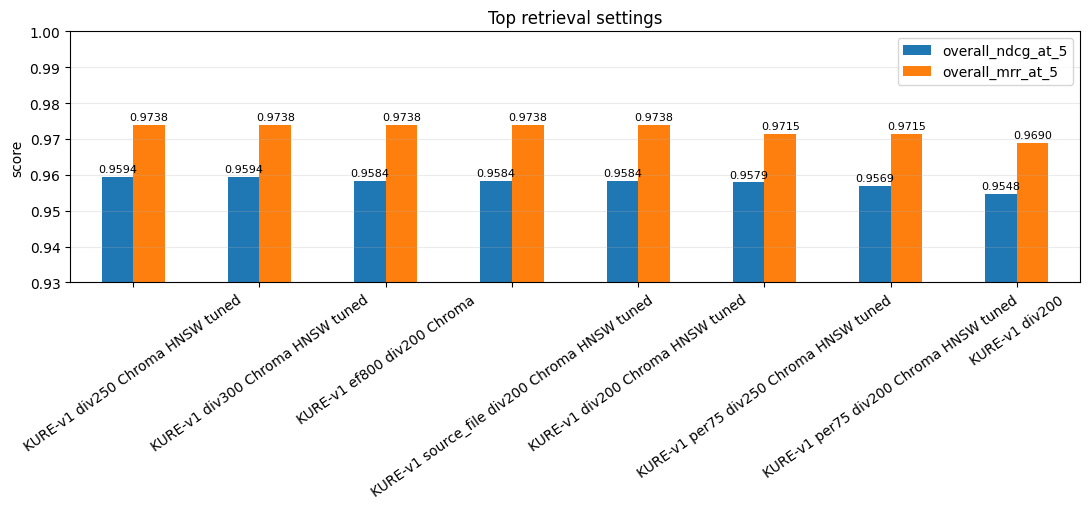

In [55]:
top_plot = final_compare.head(8).copy()
plot_df = top_plot.set_index("setting")[["overall_ndcg_at_5", "overall_mrr_at_5"]]

fig, ax = plt.subplots(figsize=(11, 5.2))
plot_df.plot(kind="bar", ax=ax, rot=35)
ax.set_title("Top retrieval settings")
ax.set_xlabel("")
ax.set_ylabel("score")
ax.set_ylim(0.93, 1.0)
ax.grid(axis="y", alpha=0.25)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()


## 3. Chroma 튜닝 결과

처음에는 FAISS가 Chroma보다 높았지만, 그때의 Chroma는 metadata filter와 HNSW 설정을 충분히 활용하지 못한 상태였다.

튜닝 순서는 다음과 같았다.

1. Chroma metadata를 `_chunk_json` 문자열 하나가 아니라 `issuer`, `source_file`, `project_name`, `doc_id` 필드로 분리
2. 가능한 경우 Chroma 내부 `where` filter 사용
3. HNSW 검색 정확도 개선: `ef_search=400`, `ef_construction=200`, `max_neighbors=32`
4. `diversity_candidates`, `per_query`, `diversity_key`, `ef_search` 조합 비교


In [56]:
chroma_names = [
    "71_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per50_diverse200_soyeon_125_kure_faiss_canonical",
    "73_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per50_diverse200_soyeon_125_kure_chroma_hnsw_tuned_canonical",
    "74_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per50_diverse250_soyeon_125_kure_chroma_hnsw_tuned_canonical",
    "75_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per50_diverse300_soyeon_125_kure_chroma_hnsw_tuned_canonical",
    "76_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per75_diverse200_soyeon_125_kure_chroma_hnsw_tuned_canonical",
    "77_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per75_diverse250_soyeon_125_kure_chroma_hnsw_tuned_canonical",
    "78_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per50_diverse200_source_file_soyeon_125_kure_chroma_hnsw_tuned_canonical",
    "79_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per50_diverse200_soyeon_125_kure_chroma_hnsw_ef800_canonical",
]

chroma_tuning = final_compare[final_compare["experiment_name"].isin(chroma_names)].copy()
chroma_tuning = chroma_tuning[[
    "setting", "overall_hit_at_5", "overall_mrr_at_5", "overall_ndcg_at_5",
    "type_b_ndcg_at_5", "elapsed", "notes",
]].sort_values(["overall_ndcg_at_5", "elapsed"], ascending=[False, True])

chroma_tuning


,setting,overall_hit_at_5,overall_mrr_at_5,overall_ndcg_at_5,type_b_ndcg_at_5,elapsed,notes
0,KURE-v1 div250 Chroma HNSW tuned,1.0,0.973833,0.959371,0.914900,1:29.39,final_selected_chroma_hnsw_tuned_diversity250_with_analysis_metrics
1,KURE-v1 div300 Chroma HNSW tuned,1.0,0.973833,0.959371,0.914900,1:31.56,chroma_hnsw_tuned_diversity300
2,KURE-v1 ef800 div200 Chroma,1.0,0.973833,0.958395,0.912460,1:34.10,chroma_hnsw_ef_search800_compare_with_73
3,KURE-v1 source_file div200 Chroma HNSW tuned,1.0,0.973833,0.958394,0.912459,1:26.62,chroma_hnsw_tuned_source_file_diversity200
4,KURE-v1 div200 Chroma HNSW tuned,1.0,0.973833,0.958394,0.912459,1:52.22,chroma_hnsw_tuned_ef_search400_compare_with_faiss_71
5,KURE-v1 per75 div250 Chroma HNSW tuned,1.0,0.971500,0.957915,0.911260,1:33.38,chroma_hnsw_tuned_per_query75_diversity250
6,KURE-v1 per75 div200 Chroma HNSW tuned,1.0,0.971500,0.956939,0.908820,1:29.01,chroma_hnsw_tuned_per_query75_diversity200
7,KURE-v1 div200,1.0,0.969000,0.954780,0.912460,1:42.84,final_setting_kure_diversity200_check


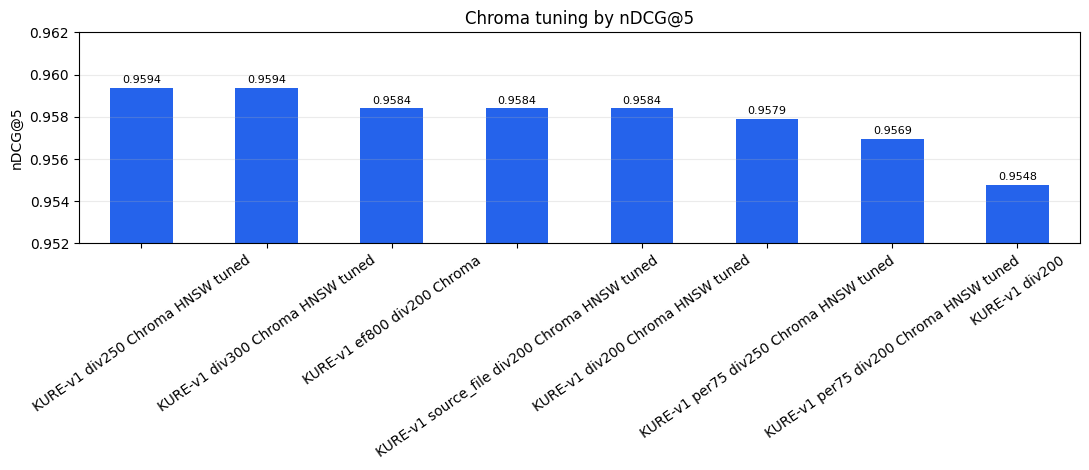

In [57]:
fig, ax = plt.subplots(figsize=(11, 4.8))
plot_df = chroma_tuning.set_index("setting")[["overall_ndcg_at_5"]]
plot_df.plot(kind="bar", ax=ax, legend=False, color="#2563eb", rot=35)
ax.set_title("Chroma tuning by nDCG@5")
ax.set_xlabel("")
ax.set_ylabel("nDCG@5")
ax.set_ylim(0.952, 0.962)
ax.grid(axis="y", alpha=0.25)
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", fontsize=8, padding=2)
plt.tight_layout()
plt.show()


## 4. 실험 해석

주요 해석은 다음과 같다.

- `diversity_candidates=250`이 현재 데이터에서는 가장 효율적이다.
- `diversity_candidates=300`은 같은 점수지만 더 느리다.
- `per_query=75`는 후보를 더 많이 보지만 잡음도 같이 늘어 점수가 내려갔다.
- `ef_search=800`은 `ef_search=400`보다 아주 조금 좋아졌지만, `diversity250` 조합을 넘지는 못했다.
- `source_file` diversity는 속도는 빠르지만 점수는 `doc_id + diversity250`보다 낮다.


## 5. nDCG 기준 부분 실패 분석

최종 74번은 `hit@5=1.0`이라 완전 오답은 없다. 다만 `ndcg@5 < 1`인 부분 실패는 남아 있다.

해석 기준:

- `missing_gt_doc`: 여러 정답 문서 중 일부가 top-5에서 빠진 경우
- `rank_not_first`: 정답 문서는 찾았지만 1순위가 아닌 경우
- `other_ndcg_loss`: 정답은 찾았지만 순서나 추가 문서 때문에 nDCG가 1이 아닌 경우


In [58]:
import ast
import textwrap

failure_path = EVAL_DIR / "ndcg_failures_74_kure_chroma_hnsw_tuned_diverse250.csv"
failures = pd.read_csv(failure_path)

def _parse_list(value):
    if pd.isna(value):
        return []
    if isinstance(value, list):
        return value
    try:
        return json.loads(value)
    except Exception:
        try:
            return ast.literal_eval(value)
        except Exception:
            return [str(value)]

def _short_doc_list(value, limit=3, width=42):
    docs = _parse_list(value)
    if not docs:
        return ""
    lines = []
    for idx, doc in enumerate(docs[:limit], start=1):
        lines.append(f"{idx}. " + textwrap.shorten(str(doc), width=width, placeholder="..."))
    if len(docs) > limit:
        lines.append(f"... +{len(docs) - limit} more")
    return "\n".join(lines)

def _failure_pattern(row):
    if row["matched_doc_count"] < row["ground_truth_doc_count"]:
        return "missing_gt_doc"
    if row["first_relevant_rank"] > 1:
        return "rank_not_first"
    return "other_ndcg_loss"

failures["missing_doc_count"] = failures["ground_truth_doc_count"] - failures["matched_doc_count"]
failures["failure_pattern"] = failures.apply(_failure_pattern, axis=1)
failures["difficulty_en"] = failures["difficulty"].map({"상": "hard", "중": "medium", "하": "easy"}).fillna(failures["difficulty"])
failures["retrieved_docs_short"] = failures["retrieved_doc_ids"].apply(_short_doc_list)
failures["ground_truth_docs_short"] = failures["ground_truth_docs"].apply(_short_doc_list)

failure_overview = pd.DataFrame([
    {"metric": "total_eval_questions", "value": 500},
    {"metric": "ndcg_less_than_1", "value": len(failures)},
    {"metric": "hit_misses", "value": int((failures["hit_at_5"] < 1).sum())},
    {"metric": "mean_failure_ndcg", "value": round(failures["ndcg_at_5"].mean(), 4)},
    {"metric": "mean_failure_doc_recall", "value": round(failures["doc_recall_at_5"].mean(), 4)},
])

failure_overview


,metric,value
0,total_eval_questions,500.0000
1,ndcg_less_than_1,85.0000
2,hit_misses,0.0000
3,mean_failure_ndcg,0.7610
4,mean_failure_doc_recall,0.8706


In [59]:
pattern_summary = (
    failures
    .groupby(["failure_pattern", "type"], dropna=False)
    .agg(
        count=("id", "count"),
        mean_ndcg=("ndcg_at_5", "mean"),
        mean_doc_recall=("doc_recall_at_5", "mean"),
        mean_missing_docs=("missing_doc_count", "mean"),
    )
    .reset_index()
    .sort_values(["count", "mean_ndcg"], ascending=[False, True])
)

pattern_summary


,failure_pattern,type,count,mean_ndcg,mean_doc_recall,mean_missing_docs
2,other_ndcg_loss,B,37,0.912203,1.0,0.00
0,missing_gt_doc,B,25,0.644951,0.6,1.08
4,rank_not_first,B,14,0.650337,1.0,0.00
5,rank_not_first,C,3,0.630930,1.0,0.00
1,missing_gt_doc,E,2,0.613147,0.5,1.00
6,rank_not_first,D,2,0.630930,1.0,0.00
3,rank_not_first,A,1,0.630930,1.0,0.00
7,rank_not_first,E,1,0.693426,1.0,0.00


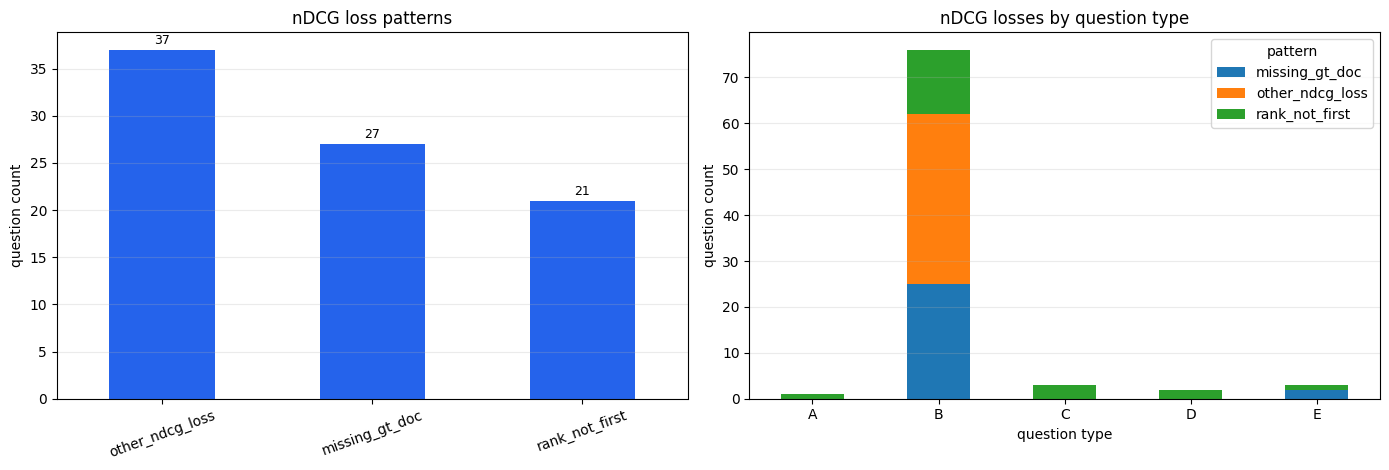

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))

failures["failure_pattern"].value_counts().plot(kind="bar", ax=axes[0], color="#2563eb", rot=20)
axes[0].set_title("nDCG loss patterns")
axes[0].set_xlabel("")
axes[0].set_ylabel("question count")
axes[0].grid(axis="y", alpha=0.25)
for container in axes[0].containers:
    axes[0].bar_label(container, fontsize=9, padding=2)

type_counts = failures.groupby(["type", "failure_pattern"]).size().unstack(fill_value=0)
type_counts.plot(kind="bar", stacked=True, ax=axes[1], rot=0)
axes[1].set_title("nDCG losses by question type")
axes[1].set_xlabel("question type")
axes[1].set_ylabel("question count")
axes[1].grid(axis="y", alpha=0.25)
axes[1].legend(title="pattern", loc="upper right")

plt.tight_layout()
plt.show()


In [61]:
priority_cols = [
    "id", "type", "difficulty_en", "failure_pattern",
    "ndcg_at_5", "mrr_at_5", "first_relevant_rank",
    "ground_truth_doc_count", "matched_doc_count", "missing_doc_count", "doc_recall_at_5",
    "retrieved_docs_short", "ground_truth_docs_short",
]

priority_failures = (
    failures
    .sort_values(["ndcg_at_5", "missing_doc_count", "first_relevant_rank"], ascending=[True, False, False])
    [priority_cols]
    .head(20)
)

priority_failures


,id,type,difficulty_en,failure_pattern,ndcg_at_5,mrr_at_5,first_relevant_rank,ground_truth_doc_count,matched_doc_count,missing_doc_count,doc_recall_at_5,retrieved_docs_short,ground_truth_docs_short
0,Q449,B,easy,missing_gt_doc,0.264068,0.250000,4.0,2,1,1,0.500000,1. KOICA 전자조달_[지문] [국제] (재공고)우즈베키스탄 ICT기반의...\n2. (재)예술경영지원센터_통합 정보시스템 구축 사전 컨설팅.hwp\n3. KOICA 전자조달_[긴급] [지문] [국제] 우...,1. 사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp\n2. (사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발...
1,Q468,B,easy,missing_gt_doc,0.264068,0.250000,4.0,2,1,1,0.500000,1. KOICA 전자조달_[긴급] [지문] [국제] 우즈베키스탄 열린...\n2. KOICA 전자조달_[지문] [국제] (재공고)우즈베키스탄 ICT기반의...\n3. KOICA_(재공고) 몽골 철도안전 통합관...,1. 사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp\n2. (사)부산국제영화제_2024년 BIFF & ACFM 온라인서비스 재개발...
2,Q354,B,hard,missing_gt_doc,0.469279,1.000000,1.0,3,1,2,0.333333,1. 서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.pdf\n2. 고려대학교_차세대 포털·학사 정보시스템 구축사업.pdf\n3. 한국철도공사 (용역)_중장기 정보화전략계획(ISP) 수정...,1. 서울시립대학교_[사전공개] 학업성취도 다차원 종단분석 통합시스템 1차.pdf\n2. 한국철도공사 (용역)_모바일오피스 시스템 고도화 용역(총체 및 1차).hwp\n3. 한국원자력연구원_한국원자력연구원 선...
3,Q413,B,hard,missing_gt_doc,0.469279,1.000000,1.0,3,1,2,0.333333,1. 남서울대학교_[혁신-국고] 남서울대학교 스마트 정보시스템 활성화(학사.hwp\n2. 한국수자원공사_국산 표준수운영시스템(iWater Neo) 최적화 및...\n3. 한국연구재단_2024년 대학산학협력활동...,"1. 사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp\n2. 서울특별시 여성가족재단_(재공고, 협상) 서울 디지털성범죄 안심지원센.hwp\n3. 남서울대학교_[혁신-국고] 남서울대학교 스..."
4,Q132,B,medium,rank_not_first,0.501266,0.250000,4.0,2,2,0,1.000000,1. 경희대학교산학협력단_산학협력단 정보시스템 운영 용역업체 선정.hwp\n2. 경희대학교_[재공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp\n3. 경희대학교산학협력단_[재공고] 산학협력단 정보시스템...,1. 인천공항운영서비스(주)_인천공항운영서비스㈜ 차세대 ERP시스템 구축 .hwp\n2. 경희대학교_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp
5,Q332,B,medium,rank_not_first,0.543771,0.333333,3.0,2,2,0,1.000000,1. 경희대학교_[재공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp\n2. 경희대학교산학협력단_산학협력단 정보시스템 운영 용역업체 선정.hwp\n3. 경희대학교_[입찰공고] 산학협력단 정보시스템 운영 ...,1. 대한상공회의소_기업 재생에너지 지원센터 홈페이지 개편 및 시스템 고.hwp\n2. 경희대학교_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp
6,Q373,B,medium,rank_not_first,0.570642,0.333333,3.0,2,2,0,1.000000,1. 경희대학교_[재공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp\n2. 경희대학교산학협력단_[재공고] 산학협력단 정보시스템 운영 용역업체 .hwp\n3. 대한상공회의소_기업 재생에너지 지원센터 홈페...,1. 대한상공회의소_기업 재생에너지 지원센터 홈페이지 개편 및 시스템 고.hwp\n2. 경희대학교_[입찰공고] 산학협력단 정보시스템 운영 용역업체 선정.hwp
7,Q494,B,hard,missing_gt_doc,0.592512,0.500000,2.0,4,3,1,0.750000,"1. KOICA 전자조달_[지문] [국제] (재공고)우즈베키스탄 ICT기반의...\n2. 서울특별시 여성가족재단_(재공고, 협상) 서울 디지털성범죄 안심지원센.hwp\n3. (사)부산국제영화제_2024년 BI...","1. 사단법인아시아물위원회사무국_우즈벡-키르기즈스탄 기후변화대응 스.hwp\n2. 서울특별시 여성가족재단_(재공고, 협상) 서울 디지털성범죄 안심지원센.hwp\n3. (사)부산국제영화제_2024년 BIFF &..."
8,Q088,B,easy,missing_gt_doc,0.613147,1.000000,1.0,2,1,1,0.500000,1. 한국수출입은행_(긴급) 모잠비크 마푸토 지능형교통시스템(ITS)...\n2. KOICA 전자조달_[지문] [국제] (재공고)우즈베키스탄 ICT기반의...\n3. 한국수자원공사_국산 표준수운영시스템(iWa...,1. 한국수자원공사_용인 첨단 시스템반도체 국가산단 용수공급사업 타당성.hwp\n2. 한국수출입은행_(긴급) 모잠비크 마푸토 지능형교통시스템(ITS)...
9,Q268,B,easy,missing_gt_doc,0.613147,1.000000,1.0,2,1,1,0.500000,1. 한국보건산업진흥원_의료기기산업 종합정보시스템(정보관리기관) 기능.hwp\n2. BioIN_의료기기산업 종합정보시스템(정보관리기관) 기능개선...\n3. 국립중앙의료원_병원정보시스템 노후 전산장비 교체(증...,1. 한국보건산업진흥원_의료기기산업 종합정보시스템(정보관리기관) 기능.hwp\n2. 국방과학연구소_기록관리시스템 통합 활용 및 보안 환경 구축.hwp


## 6. 최종 재현 명령어

현재 최종 재현은 아래 순서다. Chroma index 생성 시 HNSW 설정은 `src/vectorstore/chroma_store.py`의 `HNSW_CONFIG`에 들어 있다.


```bash
.venv/bin/python scripts/build_vector_index.py   --vector-store chroma   --chunks indexes/faiss_kure_v1_soyeon_125_260520_chunks_v2_125/chunks.json   --embedding-preset kure   --index-dir indexes/chroma_kure_v1_soyeon_125_260520_chunks_v2_125
```

```bash
.venv/bin/python scripts/generate_eval_predictions.py   --retriever dense   --vector-store chroma   --index-dir indexes/chroma_kure_v1_soyeon_125_260520_chunks_v2_125   --chunks indexes/faiss_kure_v1_soyeon_125_260520_chunks_v2_125/chunks.json   --embedding-preset kure   --query-decomposition   --decomposition-conditional   --decomposition-candidates-per-query 50   --decomposition-max-queries 8   --decomposition-selection rrf   --document-diversity   --diversity-candidates 250   --diversity-key doc_id   --no-expand-multi-agency-filter   --canonical-only   --output outputs/predictions/74_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per50_diverse250_soyeon_125_kure_chroma_hnsw_tuned_canonical.jsonl
```

```bash
.venv/bin/python eval/scripts/run_evaluation.py   --predictions outputs/predictions/74_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per50_diverse250_soyeon_125_kure_chroma_hnsw_tuned_canonical.jsonl   --canonical-only   --include-analysis-metrics   --experiment-name 74_dense_conditional_qdecomp_v2_rrf_multi_relaxed_filter_kept_per50_diverse250_soyeon_125_kure_chroma_hnsw_tuned_canonical   --notes final_selected_chroma_hnsw_tuned_diversity250_with_analysis_metrics
```


## 7. 남은 개선 후보

현재 후보 수 튜닝만으로는 상승 폭이 작아지는 구간에 들어왔다. 다음 개선은 retrieval parameter보다 데이터와 query decomposition 품질 쪽이 더 가능성이 크다.

- 문서명/기관명 alias 정규화 보강
- type B 질문에 특화된 query decomposition 개선
- cross-encoder 또는 LLM 기반 reranker 재검토
- 중복 chunk와 유사 공고 문서 정리
- 정답 문서가 여러 개인 질문의 failure case를 기준으로 데이터 보강
